# Specifying & Verifying Your ML Models

**Audience:** ML practitioners who want to add V&V rigor to their models without learning an entirely new discipline.

**What you'll learn:**
1. How to wrap a PyTorch model for automated assessment
2. How to define specs with concrete, testable criteria
3. How to run assessments and generate compliance reports
4. How hook-based inspection and property testing work

**Prerequisites:** PyTorch installed (`pip install vnvspec[torch]`)

**Time:** ~30 minutes

---

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import torch
import torch.nn as nn
print(f"PyTorch: {torch.__version__}")

import vnvspec
print(f"vnvspec: {vnvspec.__version__}")

from vnvspec import Spec, Requirement, Evidence, IOContract, Invariant
from vnvspec.core.assessment import Report
from vnvspec.torch import TorchAdapter, HookManager, SampleBudgetIterator
from vnvspec.exporters import export_html, export_markdown, export_gsn_mermaid
from vnvspec.runners.pytest_gen import generate_pytest

from _helpers import (
    display_requirements_table, display_evidence_table,
    display_report_summary, display_violations_table,
    plot_evidence_verdicts, plot_coverage,
    display_mermaid, display_registry_sample,
)
print("All imports ready.")

PyTorch: 2.11.0
vnvspec: 0.2.0
All imports ready.


## 2. Why Specs Matter for ML

You wouldn't deploy a web service without an API contract. Yet ML models routinely ship with nothing more than "accuracy = 0.94 on test set."

**What can go wrong without specs:**
- Model outputs NaN under certain inputs (silent failure)
- Probability outputs > 1.0 after a "harmless" refactor
- Latency regresses 10x after adding a new layer
- Model works perfectly on English but fails on Arabic

**A spec is your model's contract with the rest of the system.**

## 3. Build a Simple Model

In [2]:
class TabularMLP(nn.Module):
    """3-layer MLP for tabular classification (10 features -> 3 classes)."""

    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(10, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 3),
            nn.Softmax(dim=-1),
        )

    def forward(self, x):
        return self.layers(x)

model = TabularMLP()
print(model)
print(f"\nParameters: {sum(p.numel() for p in model.parameters()):,}")

TabularMLP(
  (layers): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=3, bias=True)
    (5): Softmax(dim=-1)
  )
)

Parameters: 2,883


## 4. Define the Spec

In [3]:
spec = Spec(
    name="tabular-mlp-v1",
    version="1.0.0",
    requirements=[
        Requirement(
            id="REQ-PROB",
            statement="The model shall produce probabilities in [0.0, 1.0].",
            rationale="Downstream decision logic assumes valid probabilities.",
            verification_method="test",
            acceptance_criteria=["All output values in [0.0, 1.0]."],
            priority="high",
        ),
        Requirement(
            id="REQ-SUM",
            statement="The model shall produce probabilities that sum to 1.0 within 0.01 tolerance.",
            rationale="Probability simplex constraint.",
            verification_method="test",
            acceptance_criteria=["abs(sum(probs) - 1.0) < 0.01 for all samples."],
        ),
        Requirement(
            id="REQ-DIM",
            statement="The model shall output exactly 3 class scores per sample.",
            rationale="3-class classification task.",
            verification_method="test",
            acceptance_criteria=["Output shape[-1] == 3."],
        ),
        Requirement(
            id="REQ-NAN",
            statement="The model shall not produce NaN or Inf values in any output.",
            rationale="NaN propagation causes silent downstream failures.",
            verification_method="test",
            acceptance_criteria=["No NaN or Inf in output tensor."],
            priority="high",
        ),
        Requirement(
            id="REQ-DETERMINISTIC",
            statement="The model shall produce identical outputs for identical inputs in eval mode.",
            rationale="Reproducibility for debugging and auditing.",
            verification_method="test",
            acceptance_criteria=["output1 == output2 for same input."],
        ),
    ],
)

# Quality gate
all_v = []
for r in spec.requirements:
    all_v.extend(r.check_quality())
print(f"GtWR violations: {len(all_v)}")
display_requirements_table(spec.requirements)

GtWR violations: 4


ID,Statement,Method,Priority
REQ-PROB,"The model shall produce probabilities in [0.0, 1.0].",test,high
REQ-SUM,The model shall produce probabilities that sum to 1.0 within 0.01 tolerance.,test,medium
REQ-DIM,The model shall output exactly 3 class scores per sample.,test,medium
REQ-NAN,The model shall not produce NaN or Inf values in any output.,test,high
REQ-DETERMINISTIC,The model shall produce identical outputs for identical inputs in eval mode.,test,medium


## 5. Wrap with TorchAdapter

`TorchAdapter` wraps your `nn.Module` and provides the `ModelAdapter` protocol:

In [4]:
adapter = TorchAdapter(
    model,
    device="cpu",
    sample_budget=500,
    batch_size=64,
)

print(f"Adapter info: {adapter.describe()}")
print(f"Batch size hint: {adapter.batch_size_hint()}")
print(f"Streaming: {adapter.supports_streaming()}")

Adapter info: {'class': 'TabularMLP', 'device': 'cpu', 'parameters': 2883}
Batch size hint: 64
Streaming: False


## 6. Manual Verification

In [5]:
# Generate test data
test_data = [torch.randn(10) for _ in range(500)]

# Quick manual checks
sample_batch = torch.stack(test_data[:16])
output = adapter.forward(sample_batch)

print(f"Input shape:  {sample_batch.shape}")
print(f"Output shape: {output.shape}")
print(f"Output range: [{output.min():.6f}, {output.max():.6f}]")
print(f"Sum per row:  {output.sum(dim=-1)[:5]}")
print(f"Any NaN:      {output.isnan().any()}")
print(f"Any Inf:      {output.isinf().any()}")

Input shape:  torch.Size([16, 10])
Output shape: torch.Size([16, 3])
Output range: [0.264751, 0.411278]
Sum per row:  tensor([1., 1., 1., 1., 1.])
Any NaN:      False
Any Inf:      False


## 7. Automated Assessment

`adapter.assess()` runs the model on all data, evaluates each requirement, and produces a `Report`:

In [6]:
report = adapter.assess(spec, test_data)

display_report_summary(report)
display_evidence_table(report.evidence)

Evidence ID,Requirement,Kind,Verdict,Observed
torch-REQ-PROB,REQ-PROB,test,pass,2026-04-17 17:45
torch-REQ-SUM,REQ-SUM,test,pass,2026-04-17 17:45
torch-REQ-DIM,REQ-DIM,test,pass,2026-04-17 17:45
torch-REQ-NAN,REQ-NAN,test,pass,2026-04-17 17:45
torch-REQ-DETERMINISTIC,REQ-DETERMINISTIC,test,pass,2026-04-17 17:45


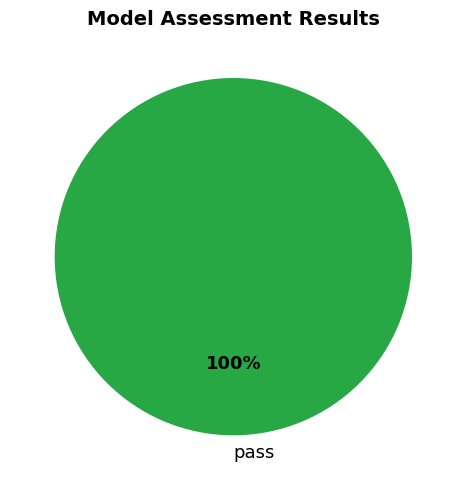

In [7]:
plot_evidence_verdicts(report.evidence, "Model Assessment Results")

## 8. Hook-Based Layer Inspection

`HookManager` lets you observe activations at any layer — useful for debugging NaN propagation, checking activation ranges, or monitoring gradient flow.

In [8]:
hm = HookManager(summary_mode=True)
hm.attach(model)

# Run a batch
with torch.no_grad():
    _ = model(torch.randn(8, 10))

# Check observations
print(f"Observed layers: {list(hm.observations.keys())}\n")
for layer_name, summaries in hm.observations.items():
    s = summaries[0]  # first (and only) observation
    print(f"{layer_name}:")
    print(f"  shape={s.shape}, dtype={s.dtype}")
    print(f"  min={s.min_val:.4f}, max={s.max_val:.4f}, mean={s.mean_val:.4f}")
    print(f"  NaN count: {s.nan_count}")
    print()

hm.detach()

Observed layers: ['layers']

layers:
  shape=(8, 3), dtype=torch.float32
  min=0.2814, max=0.3920, mean=0.3333
  NaN count: 0



## 9. Custom Verification with Evidence

For domain-specific checks, create `Evidence` objects directly:

In [9]:
import time

# Latency benchmark
model.eval()
times = []
for _ in range(100):
    x = torch.randn(1, 10)
    t0 = time.perf_counter()
    with torch.no_grad():
        _ = model(x)
    times.append((time.perf_counter() - t0) * 1000)  # ms

p50 = sorted(times)[50]
p99 = sorted(times)[99]

ev_latency = Evidence(
    id="EV-LATENCY",
    requirement_id="REQ-DETERMINISTIC",  # closest match
    kind="test",
    verdict="pass" if p99 < 50 else "fail",
    details={"p50_ms": round(p50, 3), "p99_ms": round(p99, 3), "runs": 100},
)

print(f"Latency p50: {p50:.3f} ms, p99: {p99:.3f} ms")
print(f"Verdict: {ev_latency.verdict}")

Latency p50: 0.010 ms, p99: 0.135 ms
Verdict: pass


In [10]:
# Determinism check
x = torch.randn(4, 10)
model.eval()
with torch.no_grad():
    out1 = model(x)
    out2 = model(x)

is_deterministic = torch.equal(out1, out2)
ev_determinism = Evidence(
    id="EV-DETERMINISM",
    requirement_id="REQ-DETERMINISTIC",
    kind="test",
    verdict="pass" if is_deterministic else "fail",
    details={"max_diff": float((out1 - out2).abs().max())},
)

print(f"Deterministic: {is_deterministic} (max diff: {(out1 - out2).abs().max():.2e})")

Deterministic: True (max diff: 0.00e+00)


## 10. Enhanced Report with Custom Evidence

Evidence ID,Requirement,Kind,Verdict,Observed
torch-REQ-PROB,REQ-PROB,test,pass,2026-04-17 17:45
torch-REQ-SUM,REQ-SUM,test,pass,2026-04-17 17:45
torch-REQ-DIM,REQ-DIM,test,pass,2026-04-17 17:45
torch-REQ-NAN,REQ-NAN,test,pass,2026-04-17 17:45
torch-REQ-DETERMINISTIC,REQ-DETERMINISTIC,test,pass,2026-04-17 17:45
EV-LATENCY,REQ-DETERMINISTIC,test,pass,2026-04-17 17:45
EV-DETERMINISM,REQ-DETERMINISTIC,test,pass,2026-04-17 17:45


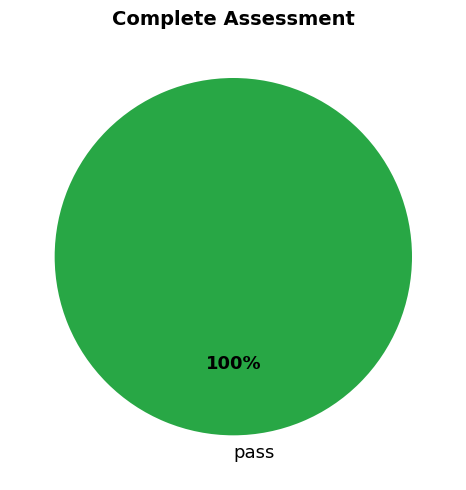

In [11]:
# Combine automated + custom evidence
all_evidence = list(report.evidence) + [ev_latency, ev_determinism]

enhanced_report = Report(
    spec_name=spec.name,
    spec_version=spec.version,
    evidence=all_evidence,
    summary={
        "samples": 500,
        "latency_p99_ms": round(p99, 3),
        "deterministic": is_deterministic,
    },
)

display_report_summary(enhanced_report)
display_evidence_table(enhanced_report.evidence)
plot_evidence_verdicts(enhanced_report.evidence, "Complete Assessment")

## 11. Export Reports

In [12]:
# HTML report (standalone, no external deps)
html = export_html(enhanced_report)
print(f"HTML report: {len(html)} chars")
print(html[:500])
print("...")

HTML report: 2200 chars
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8">
<title>V&amp;V Report — tabular-mlp-v1</title>
<style>
body { font-family: system-ui, sans-serif; margin: 2rem; color: #1a1a1a; }
h1 { border-bottom: 2px solid #0066cc; padding-bottom: .5rem; }
h2 { color: #0066cc; }
table { border-collapse: collapse; width: 100%; margin: 1rem 0; }
th, td { border: 1px solid #ccc; padding: .5rem .75rem; text-align: left; }
th { background: #f0f4f8; }
.pass { color: #16a34a; font-weight: bold; }
.fail
...


In [13]:
# GSN assurance case
gsn = export_gsn_mermaid(enhanced_report)
print(gsn)
display_mermaid(gsn)

flowchart TD
    G1["tabular-mlp-v1 v1.0.0: pass"]
    S1["REQ-DETERMINISTIC"]
    G1 --> S1
    E_EV_DETERMINISM["EV-DETERMINISM: pass"]
    S1 --> E_EV_DETERMINISM
    E_EV_LATENCY["EV-LATENCY: pass"]
    S1 --> E_EV_LATENCY
    E_torch_REQ_DETERMINISTIC["torch-REQ-DETERMINISTIC: pass"]
    S1 --> E_torch_REQ_DETERMINISTIC
    S2["REQ-DIM"]
    G1 --> S2
    E_torch_REQ_DIM["torch-REQ-DIM: pass"]
    S2 --> E_torch_REQ_DIM
    S3["REQ-NAN"]
    G1 --> S3
    E_torch_REQ_NAN["torch-REQ-NAN: pass"]
    S3 --> E_torch_REQ_NAN
    S4["REQ-PROB"]
    G1 --> S4
    E_torch_REQ_PROB["torch-REQ-PROB: pass"]
    S4 --> E_torch_REQ_PROB
    S5["REQ-SUM"]
    G1 --> S5
    E_torch_REQ_SUM["torch-REQ-SUM: pass"]
    S5 --> E_torch_REQ_SUM



## 12. Auto-Generated Test Suite

In [14]:
pytest_code = generate_pytest(spec)
print(pytest_code)

"""Auto-generated pytest tests for spec: tabular-mlp-v1."""

from __future__ import annotations

import pytest

@pytest.mark.parametrize("criterion", ['All output values in [0.0, 1.0].'])
def test_req_prob(criterion: str) -> None:
    """REQ-PROB: The model shall produce probabilities in [0.0, 1.0]."""
    # TODO: implement verification logic for REQ-PROB
    assert criterion is not None


@pytest.mark.parametrize("criterion", ['abs(sum(probs) - 1.0) < 0.01 for all samples.'])
def test_req_sum(criterion: str) -> None:
    """REQ-SUM: The model shall produce probabilities that sum to 1.0 within 0.01 tolerance."""
    # TODO: implement verification logic for REQ-SUM
    assert criterion is not None


@pytest.mark.parametrize("criterion", ['Output shape[-1] == 3.'])
def test_req_dim(criterion: str) -> None:
    """REQ-DIM: The model shall output exactly 3 class scores per sample."""
    # TODO: implement verification logic for REQ-DIM
    assert criterion is not None


@pytest.mark.parame

Save this to a `.py` file and run `pytest` — you get a runnable test suite derived directly from your spec.

## 13. Standards Context (Why This Matters)

In [15]:
display_registry_sample("nist_ai_rmf", n=6)

Clause,Title,Level,Summary
Govern,Govern function,informative,"Establishes organizational processes and structures to anticipate, identify, and..."
Govern 1,"Policies, processes, procedures, and practices",should,Requires documented organizational policies and practices for AI risk management...
Govern 1.1,Legal and regulatory compliance policies,should,Addresses policies ensuring the AI system complies with applicable legal and reg...
Govern 1.2,Trustworthy AI characteristics integration,should,"Ensures that trustworthy AI characteristics such as fairness, transparency, and ..."
Govern 2,Accountability structures,should,"Defines clear roles, responsibilities, and lines of accountability for AI risk m..."
Govern 2.1,Roles and responsibilities,should,Specifies that roles and responsibilities for AI risk management are clearly def...


These standards increasingly **require** the kind of evidence trail we just built:
- **ISO/PAS 8800**: AI safety for vehicles — requires documented V&V evidence
- **EU AI Act**: High-risk AI systems must produce technical documentation (Annex IV)
- **NIST AI RMF**: Govern → Map → Measure → Manage — requires traceable risk management

`vnvspec` gives you the data structures and export formats to satisfy these requirements without changing your ML workflow.

## Summary: Your V&V Workflow

```
1. Define spec      Spec(requirements=[...])
2. Wrap model       TorchAdapter(model)
3. Run assessment   adapter.assess(spec, data) -> Report
4. Inspect layers   HookManager.attach(model)
5. Custom checks    Evidence(..., verdict="pass")
6. Export           export_html(report), export_gsn_mermaid(report)
7. Generate tests   generate_pytest(spec) -> runnable .py file
```

**The key insight:** V&V isn't about slowing down your ML workflow — it's about making your model's contract explicit and automatically verifiable.